Geometry keys to be loaded:
['taiwan' 'ukraine' 'indonesia' 'us-midwest' 'bahamas' 'sudan'
 'south-africa' 'denmark' 'india_central-zone' 'sri-lanka' 'switzerland'
 'netherlands' 'lebanon' 'albania' 'macedonia' 'armenia' 'china'
 'india_north-eastern-zone' 'vietnam' 'india_western-zone'
 'india_northern-zone' 'india_eastern-zone' 'india_southern-zone'
 'bangladesh' 'hungary' 'israel-and-palestine' 'us-south' 'laos'
 'portugal' 'haiti-and-domrep' 'cuba' 'us-northeast' 'nicaragua' 'norway'
 'ecuador' 'philippines' 'germany']
Loading geometry: taiwan_GRAIN_v.1.0.parquet
Loading geometry: ukraine_GRAIN_v.1.0.parquet
Loading geometry: indonesia_GRAIN_v.1.0.parquet
Loading geometry: us-midwest_GRAIN_v.1.0.parquet
Loading geometry: bahamas_GRAIN_v.1.0.parquet
Loading geometry: sudan_GRAIN_v.1.0.parquet
Loading geometry: south-africa_GRAIN_v.1.0.parquet
Loading geometry: denmark_GRAIN_v.1.0.parquet
Loading geometry: india_central-zone_GRAIN_v.1.0.parquet
Loading geometry: sri-lanka_GRAIN_v.1.0

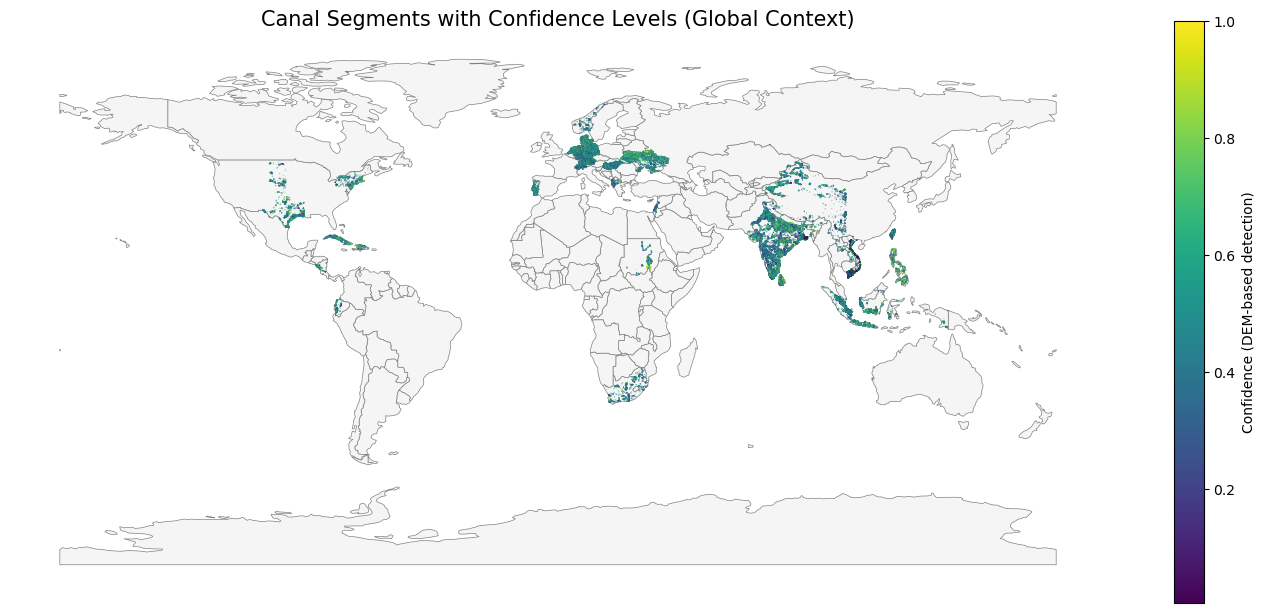

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd

import geopandas as gpd

world = gpd.read_file(
    "/home/mriduls/swot_play/SOGRAIN_Analysis/analysis/basemaps/natural_earth/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
)

# Paths

csv_path = "/home/mriduls/swot_play/SOGRAIN_Analysis/analysis/wse_dem_with_confidence.csv"

geo_base = Path("/home/mriduls/swot_play/GRAIN_v.1.0/GeoParquet")


# Load CSV

df = pd.read_csv(csv_path)

df = df[["grain_id", "region", "conf_detect_dem"]]
df["grain_id"] = df["grain_id"].astype(str)


# Geometry key logic

def get_geom_key(region):
    if region.startswith("india_"):
        return region.rsplit("_", 1)[0]
    else:
        return region.split("_")[0]

df["geom_key"] = df["region"].apply(get_geom_key)

print("Geometry keys to be loaded:")
print(df["geom_key"].unique())


# Load & merge geometries

gdf_list = []

for key in df["geom_key"].unique():
    parquet_path = geo_base / f"{key}_GRAIN_v.1.0.parquet"

    if not parquet_path.exists():
        print(f"[WARNING] Missing geometry: {parquet_path.name}")
        continue

    print(f"Loading geometry: {parquet_path.name}")

    gdf = gpd.read_parquet(parquet_path)
    gdf["grain_id"] = gdf["grain_id"].astype(str)

    df_sub = df[df["geom_key"] == key]

    gdf_merged = gdf.merge(
        df_sub,
        on="grain_id",
        how="inner"
    )

    gdf_list.append(gdf_merged)


# Combine all geometries

if not gdf_list:
    raise RuntimeError("No geometries were matched.")

gdf_plot = gpd.GeoDataFrame(
    pd.concat(gdf_list, ignore_index=True),
    crs=gdf_list[0].crs
)
world = world.to_crs(gdf_plot.crs)

print("Merged dataset size:", len(gdf_plot))


# Plot

fig, ax = plt.subplots(figsize=(14, 10))

# Background world map
world.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="gray",
    linewidth=0.5
)

# Your canal data
gdf_plot.plot(
    column="conf_detect_dem",
    cmap="viridis",
    linewidth=1.0,
    ax=ax,
    legend=True,
    legend_kwds={
        "label": "Confidence (DEM-based detection)",
        "shrink": 0.6
    }
)

ax.set_title(
    "Canal Segments with Confidence Levels (Global Context)",
    fontsize=15
)
ax.set_axis_off()

plt.tight_layout()


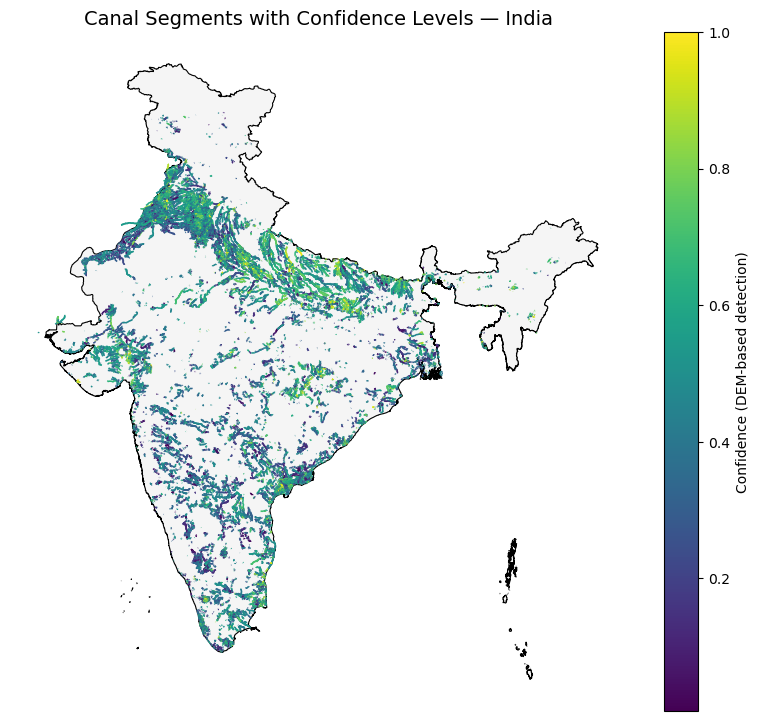

In [2]:
# Plotting India-specific map

import geopandas as gpd
from pathlib import Path

india_bg = gpd.read_file("/home/mriduls/swot_play/India-State-and-Country-Shapefile-Updated-Jan-2020-master/India_Country_Boundary.shp")

gdf_india = gdf_plot[
    gdf_plot["region"].str.startswith("india_")
].copy()
india_bg = india_bg.to_crs(gdf_india.crs)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

# India background
india_bg.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="black",
    linewidth=0.8
)

# Canal segments
gdf_india.plot(
    column="conf_detect_dem",
    cmap="viridis",
    linewidth=1.1,
    ax=ax,
    legend=True,
    legend_kwds={
        "label": "Confidence (DEM-based detection)",
        "shrink": 0.7
    }
)

ax.set_title(
    "Canal Segments with Confidence Levels — India",
    fontsize=14
)
ax.set_axis_off()

plt.tight_layout()
plt.show()

conf_class
Medium    15577
High       9061
Low        6045
Name: count, dtype: int64


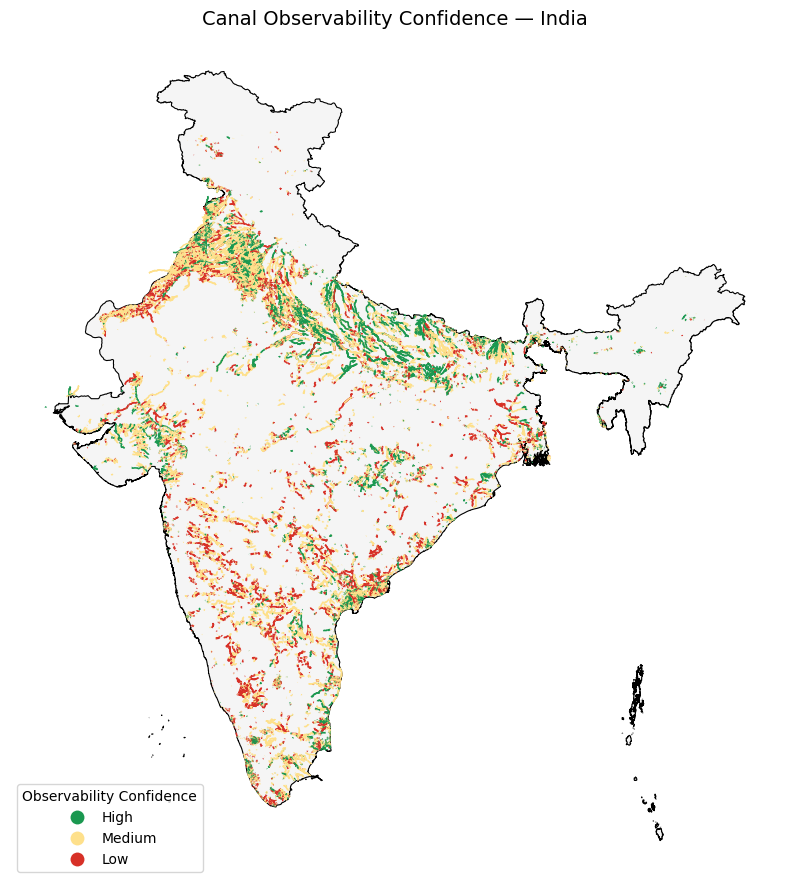

In [ ]:
import numpy as np

gdf_india["conf_class"] = np.select(
    [
        gdf_india["conf_detect_dem"] > 0.66,
        (gdf_india["conf_detect_dem"] <= 0.66) &
        (gdf_india["conf_detect_dem"] >= 0.33),
        gdf_india["conf_detect_dem"] < 0.33
    ],
    ["High", "Medium", "Low"],
    default="Unknown"   
)

gdf_india = gdf_india[
    gdf_india["conf_class"].isin(["Low", "Medium", "High"])
].copy()

# Categorical
gdf_india["conf_class"] = pd.Categorical(
    gdf_india["conf_class"],
    categories=["High", "Medium", "Low"],
    ordered=True
)

print(gdf_india["conf_class"].value_counts())
from matplotlib.colors import ListedColormap

categories = ["Low", "Medium", "High"]

cmap = ListedColormap([
    "#1a9850",  # High - green
    "#fee08b",  # Medium - yellow
    "#d73027"   # Low - red
])
fig, ax = plt.subplots(figsize=(8, 10))

india_bg.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="black",
    linewidth=0.8
)

gdf_india.plot(
    ax=ax,
    column="conf_class",
    categorical=True,
    cmap=cmap,
    linewidth=1.1,
    legend=True,
    legend_kwds={
        "title": "Observability Confidence",
        "loc": "lower left"
    }
)


ax.set_title(
    "Canal Observability Confidence — India",
    fontsize=14
)
ax.set_axis_off()

plt.tight_layout()

conf_class
Medium    11735
High       9671
Low        1612
Name: count, dtype: int64


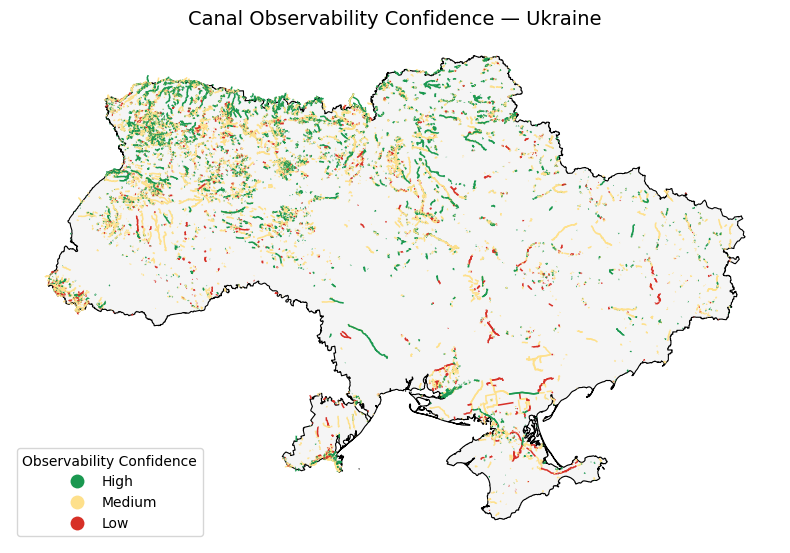

In [ ]:
# Plot any other country-specific map

import geopandas as gpd
from pathlib import Path
import numpy as np


world2 = gpd.read_file("/home/mriduls/swot_play/world_countries_updated/world_countries_updated.shp")


country = "Ukraine"  # Country Name
# Extract India (Natural Earth uses NAME = "India")
country_bg = world2[world2["CNTRY_NAME"] == country]

gdf_country = gdf_plot[
    gdf_plot["region"].str.startswith("ukraine_")
].copy()
country_bg = country_bg.to_crs(gdf_country.crs)
import matplotlib.pyplot as plt

gdf_country["conf_class"] = np.select(
    [
        gdf_country["conf_detect_dem"] > 0.66,
        (gdf_country["conf_detect_dem"] <= 0.66) &
        (gdf_country["conf_detect_dem"] >= 0.33),
        gdf_country["conf_detect_dem"] < 0.33
    ],
    ["High", "Medium", "Low"],
    default="Unknown"   
)

gdf_country = gdf_country[
    gdf_country["conf_class"].isin(["Low", "Medium", "High"])
].copy()

gdf_country["conf_class"] = pd.Categorical(
    gdf_country["conf_class"],
    categories=["High", "Medium", "Low"],
    ordered=True
)

print(gdf_country["conf_class"].value_counts())
from matplotlib.colors import ListedColormap

categories = ["Low", "Medium", "High"]

cmap = ListedColormap([
    "#1a9850",  # High - green
    "#fee08b",  # Medium - yellow
    "#d73027"   # Low - red
])
fig, ax = plt.subplots(figsize=(8, 10))

country_bg.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="black",
    linewidth=0.8
)

gdf_country.plot(
    ax=ax,
    column="conf_class",
    categorical=True,
    cmap=cmap,
    linewidth=1.1,
    legend=True,
    legend_kwds={
        "title": "Observability Confidence",
        "loc": "lower left"
    }
)


ax.set_title(
    f"Canal Observability Confidence — {country}",
    fontsize=14
)
ax.set_axis_off()

plt.tight_layout()
